# 02 Q2 Routing Control

Main-body figure notebook for routing source comparisons.

In [1]:
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

import real_final_viz_helpers as viz

importlib.reload(viz)

DATASET_LABELS = viz.DATASET_LABELS
PALETTE = viz.PALETTE
annotate_demo = viz.annotate_demo
apply_style = viz.apply_style
bar_line_panel = viz.bar_line_panel
panel_label = viz.panel_label
preview_frame = viz.preview_frame
load_csv = viz.load_csv
metric_limits = viz.metric_limits

In [2]:
q2_quality = load_csv('q2_quality.csv')
q2_profile = load_csv('q2_routing_profile.csv')

preview_frame(q2_quality)
preview_frame(q2_profile)


rows=95 cols=10
['dataset', 'variant_label', 'variant_order', 'setting_key', 'test_ndcg20', 'test_hit10', 'test_mrr20', 'base_rank', 'seed_id', 'data_status']
rows=88 cols=9
['dataset', 'setting_key', 'variant_label', 'stage_name', 'routed_family', 'usage_share', 'base_rank', 'seed_id', 'data_status']


,dataset,setting_key,variant_label,stage_name,routed_family,usage_share,base_rank,seed_id,data_status
0,KuaiRecLargeStrictPosV2_0.2,hidden_only,Hidden only,macro@1,tempo,0.0964,2,1,real
1,KuaiRecLargeStrictPosV2_0.2,hidden_only,Hidden only,macro@1,focus,0.0496,2,1,real
2,KuaiRecLargeStrictPosV2_0.2,hidden_only,Hidden only,macro@1,memory,0.0510,2,1,real
3,KuaiRecLargeStrictPosV2_0.2,hidden_only,Hidden only,macro@1,exposure,0.0837,2,1,real
4,KuaiRecLargeStrictPosV2_0.2,behavior_guided,Behavior-guided,macro@1,tempo,0.0641,1,1,real


In [3]:
apply_style()

# Q2 in the paper compares routing-source variants only.
# Keep the same five variants across both subfigures; only dataset grouping differs.
quality_plot = (
    q2_quality
    .groupby(['dataset', 'variant_label', 'variant_order'], as_index=False)[['test_ndcg20', 'test_hit10']]
    .mean()
)

variant_order = (
    quality_plot[['variant_label', 'variant_order']]
    .drop_duplicates()
    .sort_values('variant_order', kind='stable')['variant_label']
    .tolist()
)

variant_label_map = {
    'Shared FFN': 'Shared\nFFN',
    'Hidden only': 'Hidden\nonly',
    'Fusion bias': 'Fusion\nbias',
    'Mixed': 'Mixed',
    'Behavior-guided': 'Behavior\nguided',
}

quality_plot['variant_display'] = quality_plot['variant_label'].map(variant_label_map).fillna(quality_plot['variant_label'])
display_order = [variant_label_map.get(v, v) for v in variant_order]

# Requested Q2 dataset set (4): split into two panels with 2+2.
preferred_dynamic = ['KuaiRecLargeStrictPosV2_0.2', 'retail_rocket']
preferred_stable = ['lastfm0.03', 'foursquare']

available = quality_plot['dataset'].drop_duplicates().tolist()
dynamic_datasets = [d for d in preferred_dynamic if d in available]
stable_datasets = [d for d in preferred_stable if d in available]

# Fallback for draft/demo exports that may include fewer datasets.
if not dynamic_datasets or not stable_datasets:
    sorted_all = sorted(available)
    split = max(1, len(sorted_all) // 2)
    dynamic_datasets = sorted_all[:split]
    stable_datasets = sorted_all[split:] if split < len(sorted_all) else sorted_all[:1]


[saved] fig_q2_routing_control_a.pdf  -> /workspace/FeaturedMoE/writing/ACM_template/figures


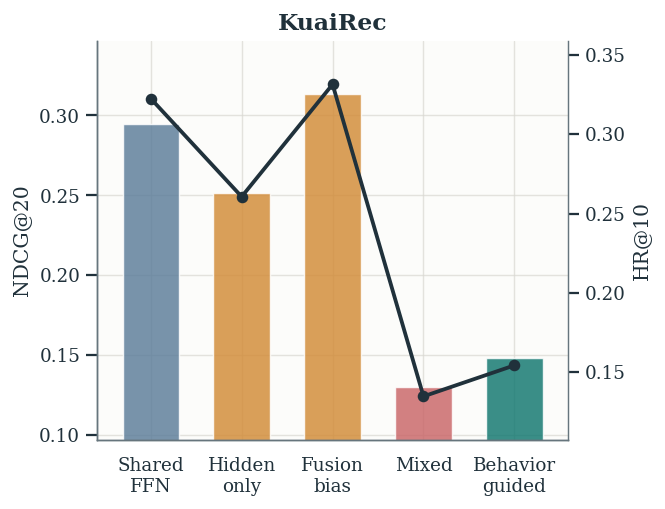

In [ ]:
# (a) Dynamic datasets: same routing-source variants, behaviorally dynamic domains.
fig, axes = plt.subplots(
    1,
    len(dynamic_datasets),
    figsize=(4.6 * len(dynamic_datasets), 2.9),
    constrained_layout=True,
)
axes = [axes] if len(dynamic_datasets) == 1 else list(axes)

for i, dataset in enumerate(dynamic_datasets):
    sub = quality_plot[quality_plot['dataset'] == dataset].copy()
    bar_line_panel(
        sub,
        category_col='variant_display',
        ndcg_col='test_ndcg20',
        hr_col='test_hit10',
        ax=axes[i],
        order=display_order,
        title=DATASET_LABELS.get(dataset, dataset),
        xrotation=0,
    )

axes[0].text(
    0.01, 0.99, '',
    transform=axes[0].transAxes, ha='left', va='top',
    fontsize=12, fontweight='semibold', color=PALETTE['ink'],
)

_fig_dir = (Path(__file__).resolve().parents[2] / 'ACM_template' / 'figures') if '__file__' in dir() \
    else (Path('..') / 'ACM_template' / 'figures').resolve()
_fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(_fig_dir / 'fig_q2_routing_control_a.pdf', bbox_inches='tight')
print(f'[saved] fig_q2_routing_control_a.pdf  -> {_fig_dir}')
plt.show()

[saved] fig_q2_routing_control_b.pdf  -> /workspace/FeaturedMoE/writing/ACM_template/figures


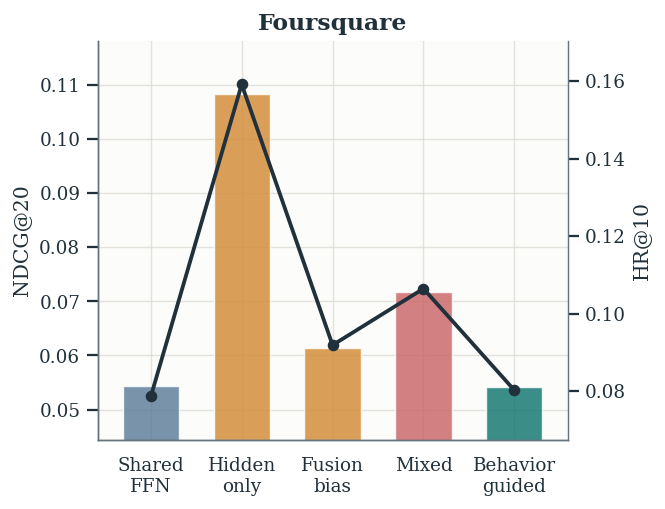

In [ ]:
# (b) Stable or mixed datasets: same routing-source variants under different behavior profile.
fig, axes = plt.subplots(
    1,
    len(stable_datasets),
    figsize=(4.6 * len(stable_datasets), 2.9),
    constrained_layout=True,
)
axes = [axes] if len(stable_datasets) == 1 else list(axes)

for i, dataset in enumerate(stable_datasets):
    sub = quality_plot[quality_plot['dataset'] == dataset].copy()
    bar_line_panel(
        sub,
        category_col='variant_display',
        ndcg_col='test_ndcg20',
        hr_col='test_hit10',
        ax=axes[i],
        order=display_order,
        title=DATASET_LABELS.get(dataset, dataset),
        xrotation=0,
    )

axes[0].text(
    0.01, 0.99, '',
    transform=axes[0].transAxes, ha='left', va='top',
    fontsize=12, fontweight='semibold', color=PALETTE['ink'],
)

_fig_dir = (Path(__file__).resolve().parents[2] / 'ACM_template' / 'figures') if '__file__' in dir() \
    else (Path('..') / 'ACM_template' / 'figures').resolve()
_fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(_fig_dir / 'fig_q2_routing_control_b.pdf', bbox_inches='tight')
print(f'[saved] fig_q2_routing_control_b.pdf  -> {_fig_dir}')
plt.show()